<a href="https://colab.research.google.com/github/jashwanth-cse/bank-fraud-transaction-analysis/blob/main/notebook/Data_Science_SAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# ROUND II - EXPLORATORY DATA ANALYSIS
# Bank Fraud Transaction Analysis
# ============================================================

import pandas as pd
from scipy.stats import chi2_contingency

# -------------------- 1. LOAD DATA --------------------

from google.colab import drive
drive.mount('/content/drive')

# Change this path only if your file is in another folder
file_path = '/content/drive/MyDrive/Q10_bank_fraud.csv'

df = pd.read_csv(file_path)

print("========== DATASET INFORMATION ==========")
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# -------------------- 2. CHECK DATA --------------------

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\nDuplicate records:", df.duplicated().sum())


# -------------------- 3. REMOVE DUPLICATES --------------------

df = df.drop_duplicates(subset='transaction_id').copy()


# -------------------- 4. FIX TIMESTAMP --------------------

df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

# Remove records with invalid timestamps
df = df.dropna(subset=['timestamp'])

# Remove records without transaction amount
df = df.dropna(subset=['transaction_amount_inr'])


# -------------------- 5. CREATE TIME-OF-DAY --------------------

def classify_time(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'


df['time_of_day'] = df['timestamp'].dt.hour.apply(classify_time)

# Keep the categories in logical order
time_order = ['Night', 'Morning', 'Afternoon', 'Evening']

df['time_of_day'] = pd.Categorical(
    df['time_of_day'],
    categories=time_order,
    ordered=True
)


# -------------------- 6. DESCRIPTIVE STATISTICS --------------------

print("\n========== TRANSACTION AMOUNT STATISTICS ==========")

print(
    df['transaction_amount_inr']
    .describe()
    .round(2)
)

print("\n========== AMOUNT BY FRAUD STATUS ==========")

print(
    df.groupby('fraud_status')['transaction_amount_inr']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)


# -------------------- 7. TIME-OF-DAY SUMMARY --------------------

print("\n========== TRANSACTIONS BY TIME OF DAY ==========")

print(
    df['time_of_day']
    .value_counts()
    .sort_index()
)


# -------------------- 8. CONTINGENCY TABLE --------------------

table = pd.crosstab(
    df['time_of_day'],
    df['fraud_status']
)

print("\n========== TIME OF DAY vs FRAUD STATUS ==========")
print(table)


# -------------------- 9. CHI-SQUARE TEST --------------------

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(table)

print("\n========== CHI-SQUARE TEST ==========")

print("Chi-Square Statistic :", round(chi2, 4))
print("Degrees of Freedom   :", degrees_of_freedom)
print("P-Value              :", round(p_value, 4))


# -------------------- 10. EXPECTED FREQUENCIES --------------------

expected_table = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print("\n========== EXPECTED FREQUENCIES ==========")
print(expected_table.round(2))


# -------------------- 11. FINAL DECISION --------------------

alpha = 0.05

print("\n========== FINAL DECISION ==========")

if p_value < alpha:
    print("Reject H0")
    print("There is a significant relationship between")
    print("time of day and fraud status.")
else:
    print("Fail to Reject H0")
    print("There is no significant relationship between")
    print("time of day and fraud status.")


# -------------------- 12. FRAUD RATE --------------------

fraud_rate = (
    df.groupby('time_of_day', observed=True)['fraud_status']
    .apply(lambda x: (x == 'Fraud').mean() * 100)
)

print("\n========== FRAUD RATE BY TIME OF DAY ==========")

print(fraud_rate.round(2))

print("\n========== CLEAN DATASET ==========")
print("Final number of records:", len(df))
# ------------------------------------------------------------
# 13. SAVE CLEANED DATASET
# ------------------------------------------------------------

cleaned_file = "Q10_bank_fraud_cleaned.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print("\n========== CLEANED DATASET SAVED ==========")
print("File:", cleaned_file)
print("Rows:", len(df))
print("Columns:", len(df.columns))

from google.colab import files

files.download(cleaned_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
========== DATASET INFORMATION ==========
Rows and Columns: (123, 5)

Columns:
['transaction_id', 'timestamp', 'transaction_amount_inr', 'time_of_day', 'fraud_status']

========== DATA TYPES ==========
transaction_id             object
timestamp                  object
transaction_amount_inr    float64
time_of_day                object
fraud_status               object
dtype: object

========== MISSING VALUES ==========
transaction_id            0
timestamp                 1
transaction_amount_inr    2
time_of_day               1
fraud_status              0
dtype: int64

Duplicate records: 3

========== TRANSACTION AMOUNT STATISTICS ==========
count      118.00
mean     10145.79
std      12838.93
min        950.52
25%       3143.52
50%       6231.26
75%      12268.86
max      87857.28
Name: transaction_amount_inr, dtype: float64

========== AMOUNT BY FRAUD ST

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

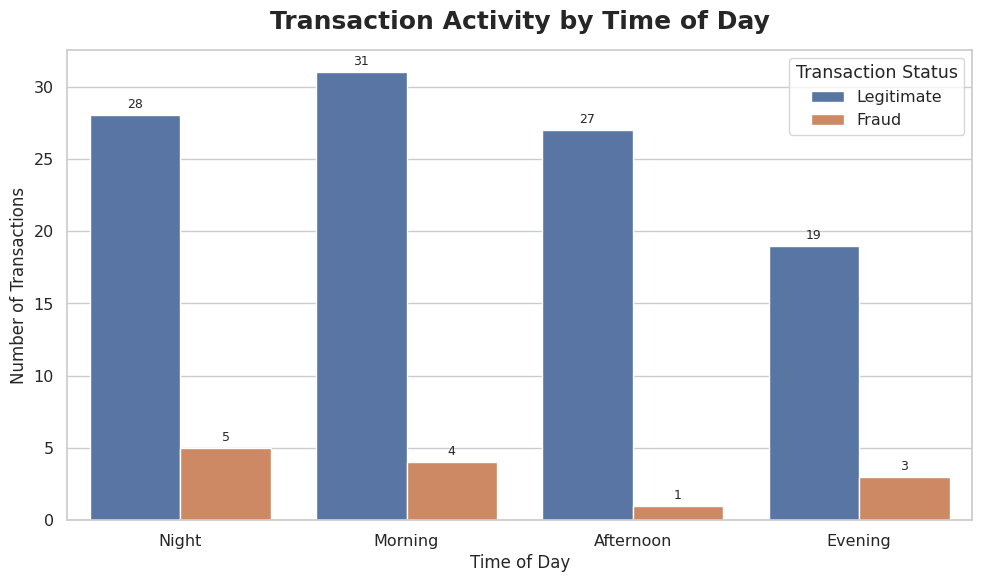

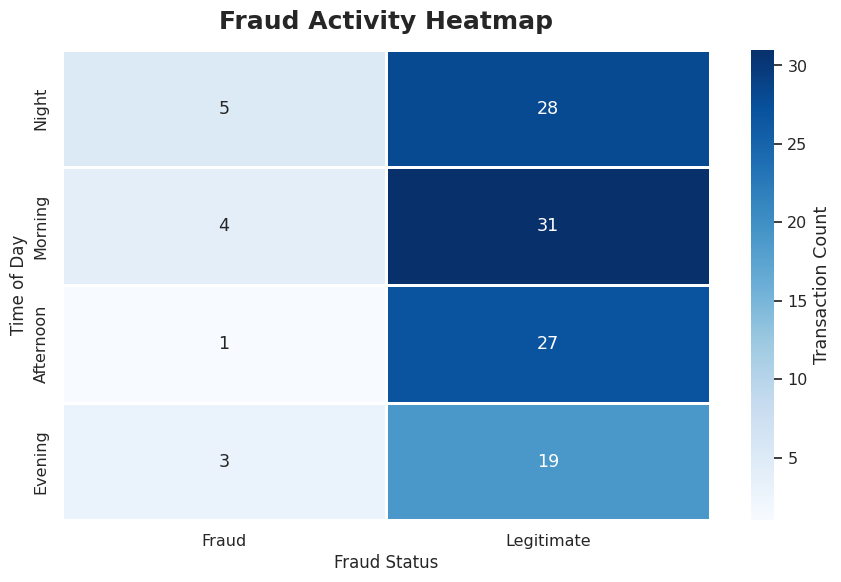

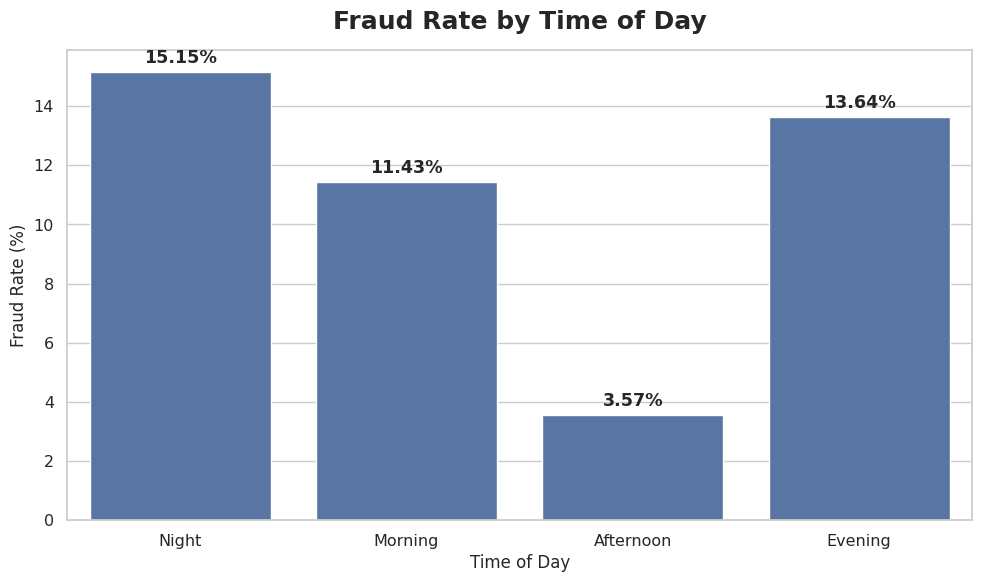

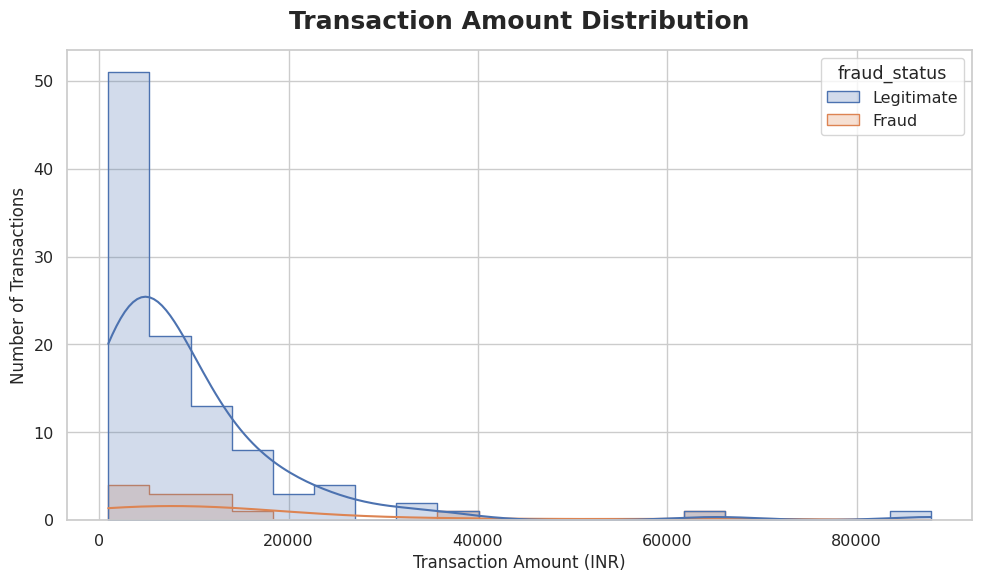

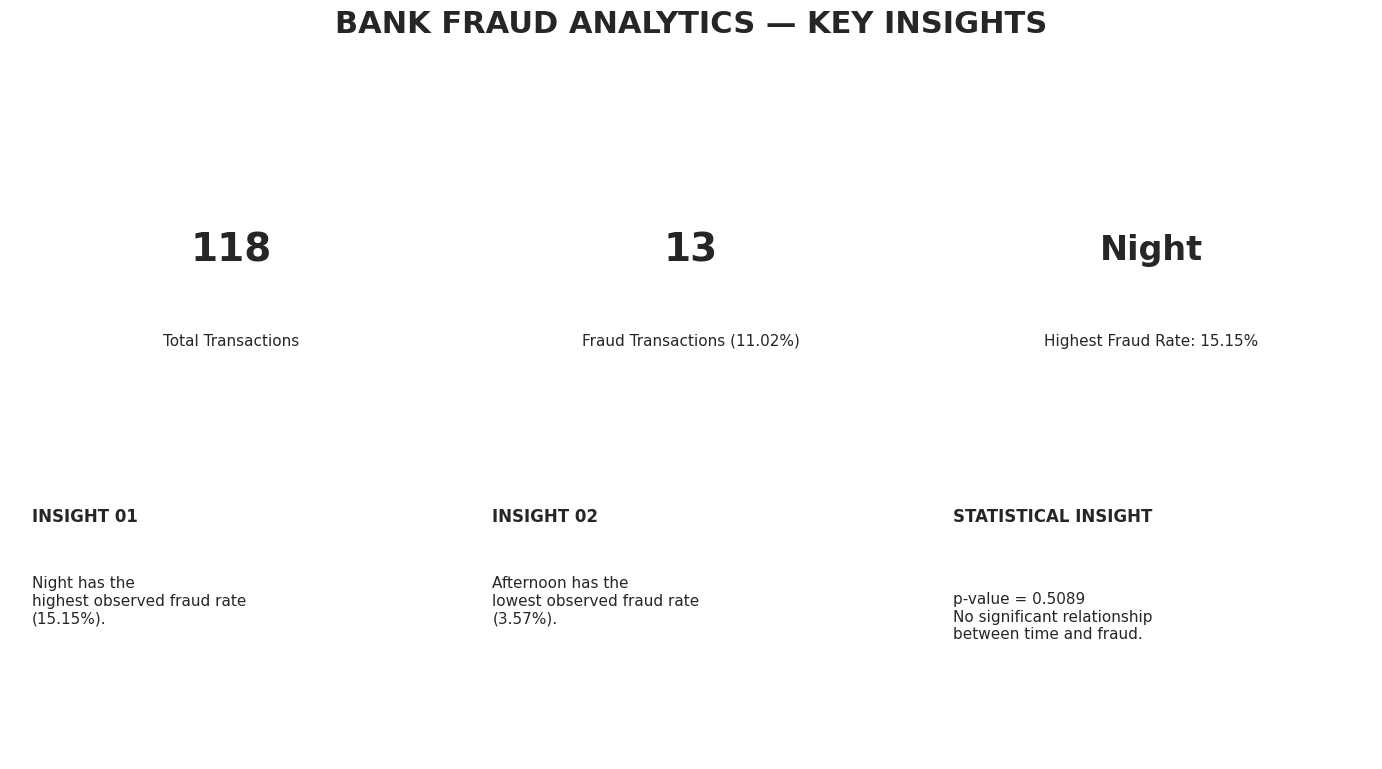



                 DATA SCIENCE INSIGHTS

1. Total Transactions      : 118
2. Fraud Transactions      : 13
3. Overall Fraud Rate      : 11.02%
4. Highest Risk Period     : Night (15.15%)
5. Lowest Risk Period      : Afternoon (3.57%)
6. Chi-Square Statistic    : 2.3188
7. P-Value                 : 0.5089

CONCLUSION:
There is no statistically significant relationship between time of day and fraud status.

RECOMMENDATION:
Use time of day as one fraud-monitoring feature, but combine it with transaction amount, customer behavior, location and transaction frequency.


In [5]:
# ============================================================
# ROUND III - DATA VISUALIZATION
# BANK FRAUD TRANSACTION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# VISUALIZATION SETTINGS
# ------------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

# Create output folder
import os
os.makedirs("visualizations", exist_ok=True)


# ============================================================
# 1. PREPARE SUMMARY DATA
# ============================================================

# Count fraud and non-fraud transactions
status_counts = (
    df["fraud_status"]
    .value_counts()
)

fraud_count = status_counts.get("Fraud", 0)
normal_count = status_counts.get("Non-Fraud", 0)

total_transactions = len(df)

fraud_percentage = (
    fraud_count / total_transactions * 100
)

# Find highest fraud-rate time period
highest_risk_time = fraud_rate.idxmax()
highest_risk_rate = fraud_rate.max()

# Find lowest fraud-rate time period
lowest_risk_time = fraud_rate.idxmin()
lowest_risk_rate = fraud_rate.min()


# ============================================================
# 2. BAR CHART - TRANSACTIONS BY TIME OF DAY
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="time_of_day",
    hue="fraud_status",
    order=[
        "Night",
        "Morning",
        "Afternoon",
        "Evening"
    ]
)

plt.title(
    "Transaction Activity by Time of Day",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Time of Day",
    fontsize=12
)

plt.ylabel(
    "Number of Transactions",
    fontsize=12
)

plt.legend(
    title="Transaction Status",
    loc="upper right"
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "visualizations/01_transactions_by_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. HEATMAP - TIME OF DAY VS FRAUD STATUS
# ============================================================

plt.figure(figsize=(9, 6))

sns.heatmap(
    table,
    annot=True,
    fmt="d",
    linewidths=1,
    cmap="Blues",
    cbar_kws={
        "label": "Transaction Count"
    }
)

plt.title(
    "Fraud Activity Heatmap",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Fraud Status",
    fontsize=12
)

plt.ylabel(
    "Time of Day",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "visualizations/02_fraud_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. FRAUD RATE BY TIME OF DAY
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=fraud_rate.index,
    y=fraud_rate.values,
    order=[
        "Night",
        "Morning",
        "Afternoon",
        "Evening"
    ]
)

plt.title(
    "Fraud Rate by Time of Day",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Time of Day",
    fontsize=12
)

plt.ylabel(
    "Fraud Rate (%)",
    fontsize=12
)

# Add percentage labels
for i, value in enumerate(fraud_rate.values):

    ax.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "visualizations/03_fraud_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. TRANSACTION AMOUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="transaction_amount_inr",
    hue="fraud_status",
    kde=True,
    bins=20,
    element="step"
)

plt.title(
    "Transaction Amount Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Transaction Amount (INR)",
    fontsize=12
)

plt.ylabel(
    "Number of Transactions",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "visualizations/04_transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. INSIGHT DASHBOARD
# ============================================================

fig = plt.figure(
    figsize=(14, 8)
)

fig.suptitle(
    "BANK FRAUD ANALYTICS — KEY INSIGHTS",
    fontsize=22,
    fontweight="bold",
    y=0.96
)


# ------------------------------------------------------------
# KPI 1 - TOTAL TRANSACTIONS
# ------------------------------------------------------------

ax1 = plt.subplot(2, 3, 1)

ax1.text(
    0.5,
    0.55,
    f"{total_transactions}",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold"
)

ax1.text(
    0.5,
    0.25,
    "Total Transactions",
    ha="center",
    fontsize=11
)

ax1.axis("off")


# ------------------------------------------------------------
# KPI 2 - FRAUD TRANSACTIONS
# ------------------------------------------------------------

ax2 = plt.subplot(2, 3, 2)

ax2.text(
    0.5,
    0.55,
    f"{fraud_count}",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold"
)

ax2.text(
    0.5,
    0.25,
    f"Fraud Transactions ({fraud_percentage:.2f}%)",
    ha="center",
    fontsize=11
)

ax2.axis("off")


# ------------------------------------------------------------
# KPI 3 - HIGHEST RISK PERIOD
# ------------------------------------------------------------

ax3 = plt.subplot(2, 3, 3)

ax3.text(
    0.5,
    0.55,
    highest_risk_time,
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax3.text(
    0.5,
    0.25,
    f"Highest Fraud Rate: {highest_risk_rate:.2f}%",
    ha="center",
    fontsize=11
)

ax3.axis("off")


# ------------------------------------------------------------
# INSIGHT 1
# ------------------------------------------------------------

ax4 = plt.subplot(2, 3, 4)

ax4.text(
    0.05,
    0.75,
    "INSIGHT 01",
    fontsize=12,
    fontweight="bold"
)

ax4.text(
    0.05,
    0.50,
    f"{highest_risk_time} has the\n"
    f"highest observed fraud rate\n"
    f"({highest_risk_rate:.2f}%).",
    fontsize=11,
    va="center"
)

ax4.axis("off")


# ------------------------------------------------------------
# INSIGHT 2
# ------------------------------------------------------------

ax5 = plt.subplot(2, 3, 5)

ax5.text(
    0.05,
    0.75,
    "INSIGHT 02",
    fontsize=12,
    fontweight="bold"
)

ax5.text(
    0.05,
    0.50,
    f"{lowest_risk_time} has the\n"
    f"lowest observed fraud rate\n"
    f"({lowest_risk_rate:.2f}%).",
    fontsize=11,
    va="center"
)

ax5.axis("off")


# ------------------------------------------------------------
# INSIGHT 3 - STATISTICAL RESULT
# ------------------------------------------------------------

ax6 = plt.subplot(2, 3, 6)

ax6.text(
    0.05,
    0.75,
    "STATISTICAL INSIGHT",
    fontsize=12,
    fontweight="bold"
)

if p_value < 0.05:

    result_text = (
        f"p-value = {p_value:.4f}\n"
        "Significant relationship\n"
        "between time and fraud."
    )

else:

    result_text = (
        f"p-value = {p_value:.4f}\n"
        "No significant relationship\n"
        "between time and fraud."
    )

ax6.text(
    0.05,
    0.45,
    result_text,
    fontsize=11,
    va="center"
)

ax6.axis("off")


plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.savefig(
    "visualizations/05_insight_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. PRINT HUMAN-READABLE INSIGHTS
# ============================================================

print("\n")
print("=" * 65)
print("                 DATA SCIENCE INSIGHTS")
print("=" * 65)

print(
    f"\n1. Total Transactions      : {total_transactions}"
)

print(
    f"2. Fraud Transactions      : {fraud_count}"
)

print(
    f"3. Overall Fraud Rate      : {fraud_percentage:.2f}%"
)

print(
    f"4. Highest Risk Period     : "
    f"{highest_risk_time} ({highest_risk_rate:.2f}%)"
)

print(
    f"5. Lowest Risk Period      : "
    f"{lowest_risk_time} ({lowest_risk_rate:.2f}%)"
)

print(
    f"6. Chi-Square Statistic    : {chi2:.4f}"
)

print(
    f"7. P-Value                 : {p_value:.4f}"
)

if p_value < 0.05:

    print(
        "\nCONCLUSION:"
        "\nThere is a statistically significant relationship "
        "between time of day and fraud status."
    )

else:

    print(
        "\nCONCLUSION:"
        "\nThere is no statistically significant relationship "
        "between time of day and fraud status."
    )

print(
    "\nRECOMMENDATION:"
    "\nUse time of day as one fraud-monitoring feature, "
    "but combine it with transaction amount, customer "
    "behavior, location and transaction frequency."
)

print("=" * 65)